In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [3]:
iris_df = pd.read_csv("iris_dataset.csv")
iris_df.shape
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
mapa_especies = {'setosa': 0, 'versicolor': 1, 'virginica': 2}
iris_df['especie_real'] = iris_df['target'].map(mapa_especies)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,especie_real
0,5.1,3.5,1.4,0.2,setosa,0
1,4.9,3.0,1.4,0.2,setosa,0
2,4.7,3.2,1.3,0.2,setosa,0
3,4.6,3.1,1.5,0.2,setosa,0
4,5.0,3.6,1.4,0.2,setosa,0


In [5]:
feature_names = iris_df.drop(columns=["target", "especie_real"]).columns
print(feature_names)

X = iris_df[feature_names]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')


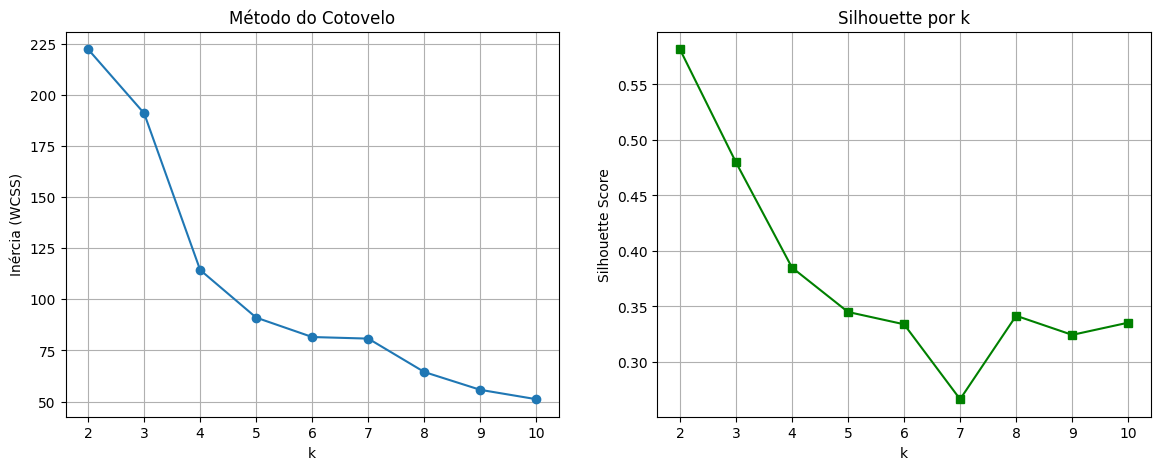

In [6]:
inercias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inercias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inércia (WCSS)')
axes[0].set_title('Método do Cotovelo')
axes[0].grid(True)

axes[1].plot(K_range, silhouettes, marker='s', color='green')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette por k')
axes[1].grid(True)

plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
iris_df['cluster'] = kmeans.fit_predict(X_scaled)

centroids = kmeans.cluster_centers_
print(f'Inércia final: {kmeans.inertia_:.2f}')
print(f'Sihouette Score: {silhouette_score(X_scaled, iris_df['cluster']):.3f}')



Inércia final: 191.02
Sihouette Score: 0.480


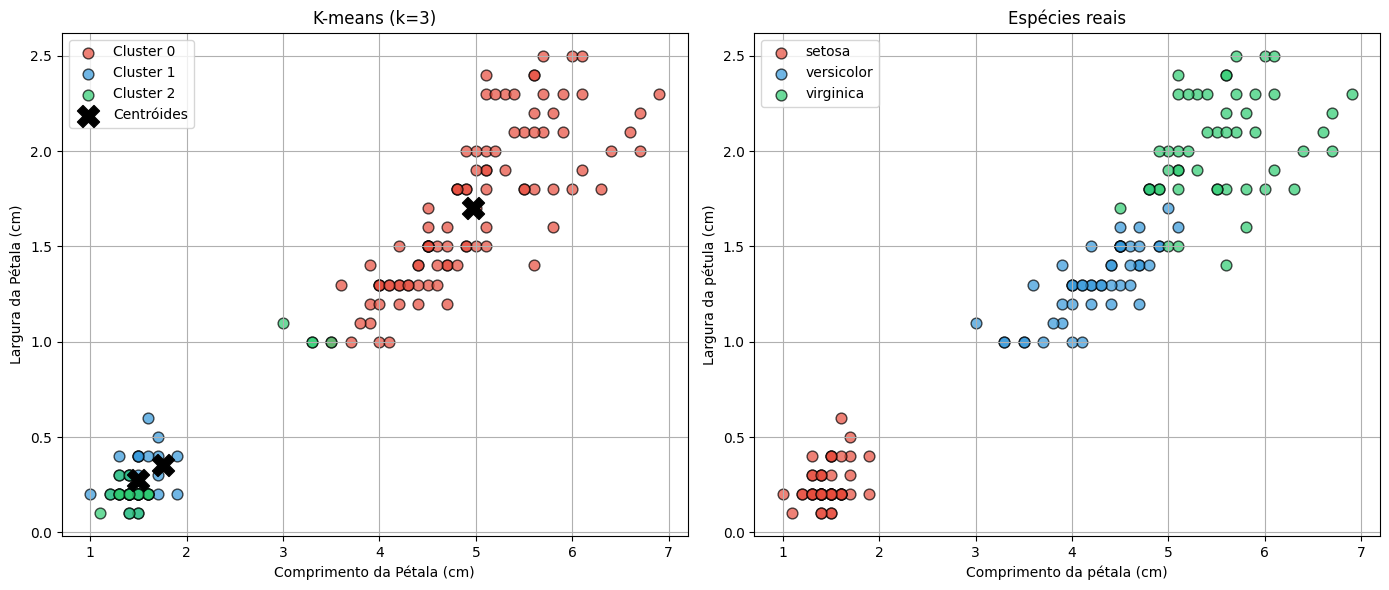

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ["#e74c3c", "#3498db", "#2ecc71"]

# Plot de clusters k-means
for c in range(3):
    subset = iris_df[iris_df['cluster'] == c]
    axes[0].scatter(subset['petal length (cm)'], subset['petal width (cm)'],
                    c=colors[c], label=f'Cluster {c}', alpha=0.7, edgecolors='k', s=60)

# Centróides (nas dimensões de pétala: índices 2 e 3)
axes[0].scatter(scaler.inverse_transform(centroids)[:, 2],
                scaler.inverse_transform(centroids)[:, 3],
                marker='X', s=250, c='black', label='Centróides', zorder=5)
axes[0].set_xlabel('Comprimento da Pétala (cm)')
axes[0].set_ylabel('Largura da Pétala (cm)')
axes[0].set_title('K-means (k=3)')
axes[0].legend()
axes[0].grid(True)  

# Plot de espécies reais (para comparação)
species_names = ['setosa', 'versicolor', 'virginica']
for s in range(3):
    subset = iris_df[iris_df['especie_real'] == s]
    axes[1].scatter(subset['petal length (cm)'], subset['petal width (cm)'],
                    c=colors[s], label=species_names[s], alpha=0.7, edgecolors='k', s=60)

axes[1].set_xlabel('Comprimento da pétala (cm)')
axes[1].set_ylabel('Largura da pétula (cm)')
axes[1].set_title('Espécies reais')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Adjusted Rand Index: 0.433


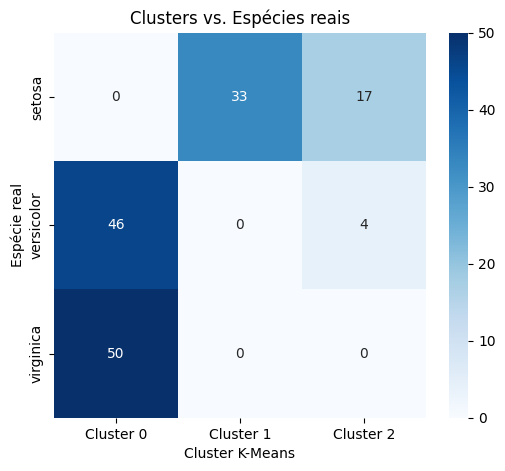

In [13]:
from sklearn.metrics import confusion_matrix, adjusted_rand_score
import seaborn as sns

# Adjusted Rand Index (mede concordância entre clusters e rótulos reais)
ari = adjusted_rand_score(iris_df["especie_real"], iris_df["cluster"])
print(f"Adjusted Rand Index: {ari:.3f}")  # ~0.73

# Matriz de confusão (os rótulos de cluster podem estar permutados)
cm = confusion_matrix(iris_df["especie_real"], iris_df["cluster"])
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[f"Cluster {i}" for i in range(3)],
    yticklabels=species_names,
)
plt.xlabel("Cluster K-Means")
plt.ylabel("Espécie real")
plt.title("Clusters vs. Espécies reais")
plt.savefig("a.png", dpi=300)
plt.show()